# Flexible inference with `condition_on`

One of ProbPipe's core operations is `condition_on(model, data)`. The same function call works whether the inference engine underneath is NUTS, RWMH, neural posterior estimation, neural likelihood estimation plus MCMC, neural ratio estimation plus MCMC, or sequential Monte Carlo ABC. ProbPipe inspects what the model supports (a combination of `SupportsLogProb`, `SupportsConditioning`, and `SupportsSampling`) and picks a registered method that can use it. We call this *protocol-based dispatch*, and the tutorial ends with a table showing how each engine below is reached from the same call site.

The running example is a small ecology problem. We use the **Ricker population model**, a discrete-time density-dependent growth model classic in fisheries and population biology. With deterministic dynamics, the likelihood is tractable and NUTS works fine. Flip on process noise and the likelihood becomes intractable, but the same class serves both regimes.

The engines we exercise:

- NUTS on the deterministic case, via `SimpleModel`.
- **NPE** (`learn_amortized_posterior`): amortized direct posterior sampling.
- **NLE** (`learn_amortized_likelihood`): an emulated likelihood that any MCMC backend can drive.
- **NRE** (`learn_amortized_ratio`): an emulated likelihood-to-evidence ratio, also MCMC-driven.
- **SMC-ABC** through the inference registry (shown below; runs once the `pyabc` backend is installed).

> **Prerequisites:** [Getting Started tutorial](getting_started.ipynb). The neural SBI engines (NPE/NLE/NRE) require `pip install probpipe[bayesflow]`; SMC-ABC requires the `pyabc` backend (a later release).

In [1]:
import warnings; warnings.simplefilter('ignore')

import io
from contextlib import contextmanager, redirect_stderr, redirect_stdout

import jax, jax.numpy as jnp, numpy as np, matplotlib.pyplot as plt
plt.rcParams['mathtext.default'] = 'regular'

from probpipe import (
    SimpleModel, SimpleGenerativeModel, Record, RecordArray,
    condition_on, learn_amortized_posterior, learn_amortized_likelihood,
    learn_amortized_ratio, ProductDistribution, Normal,
)
from probpipe.modeling import Likelihood, GenerativeLikelihood

# SMC-ABC is provided by the optional pyabc backend (a later release). The
# section that uses it runs only when pyabc is importable; everything else is
# functional with probpipe[bayesflow].
try:
    import pyabc  # noqa: F401
    HAVE_PYABC = True
except ImportError:
    HAVE_PYABC = False


@contextmanager
def silence():
    """Suppress stdout/stderr chatter (tqdm bars, training logs)."""
    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        yield

## 1. The Ricker population model

The Ricker map is a discrete-time density-dependent growth model with optional Gaussian process noise on the log-growth rate:

$$N_{t+1} = N_t \exp\!\left(r \left(1 - \frac{N_t}{K}\right) + \epsilon_t\right), \qquad \epsilon_t \sim \mathcal{N}(0, \sigma_p^2).$$

Observed counts are Poisson with rate $\phi N_t$:

$$y_t \mid N_t \sim \text{Poisson}(\phi N_t), \qquad t = 1, \ldots, T.$$

We work in log-space, $\theta = (\log r, \log K, \log \phi)$, so the prior is an independent product of normal distributions and all parameters stay positive after exponentiating. The noise scale $\sigma_p$ is a fixed setting of the model: $\sigma_p = 0$ gives the deterministic Ricker (closed-form likelihood) and any $\sigma_p > 0$ gives the stochastic Ricker (intractable likelihood). We defer the stochastic case to §5.

In [2]:
T = 40       # length of the observed time series
N0 = 5.0     # initial population size (assumed known)


class RickerObservationModel(Likelihood, GenerativeLikelihood):
    """Ricker population model with Poisson observations.

    Inheriting from both protocols makes it explicit that this class
    supplies the two APIs ProbPipe needs: ``log_likelihood`` (used by
    MCMC on a ``SimpleModel``) and ``generate_data`` (used by SBI on a
    ``SimpleGenerativeModel``).

    The ``sigma_p`` argument turns on Gaussian process noise on the
    log-growth rate.  For ``sigma_p == 0`` the trajectory is
    deterministic and ``log_likelihood`` is the exact Poisson log-pmf;
    for ``sigma_p > 0`` the latent ``N_t`` sequence is stochastic and
    the closed-form likelihood is no longer valid — ``log_likelihood``
    asserts on misuse, and only ``generate_data`` remains available.
    """

    def __init__(self, T, N0, sigma_p=0.0):
        self.T, self.N0, self.sigma_p = T, N0, sigma_p

    def _trajectory(self, params, key):
        # params arrives flat from MCMC (a parameter vector) or structured
        # from the simulator path (a per-draw record); coerce to a flat vector
        # either way. Insertion order from the prior: K, phi, r.
        theta = params.flatten() if hasattr(params, "flatten") else jnp.asarray(params)
        K, phi, r = jnp.exp(jnp.ravel(theta))
        noise = self.sigma_p * jax.random.normal(key, (self.T,))
        def step(N, eps):
            Nn = N * jnp.exp(r * (1 - N / K) + eps)
            return Nn, Nn
        _, traj = jax.lax.scan(step, self.N0, noise)
        return phi * traj

    def log_likelihood(self, params, data):
        if self.sigma_p != 0: raise NotImplementedError('closed-form likelihood only valid for sigma_p=0')
        rates = self._trajectory(params, jax.random.PRNGKey(0))
        return jnp.sum(jax.scipy.stats.poisson.logpmf(data, rates))

    def generate_data(self, params, num_observations, *, key=None):
        if key is None:
            key = jax.random.PRNGKey(0)
        def one_sim(k):
            k_proc, k_obs = jax.random.split(k)
            return jax.random.poisson(
                k_obs, self._trajectory(params, k_proc)
            ).astype(jnp.float32)
        return jax.vmap(one_sim)(jax.random.split(key, num_observations))


ricker = RickerObservationModel(T=T, N0=N0)  # sigma_p=0 → deterministic
assert isinstance(ricker, Likelihood)
assert isinstance(ricker, GenerativeLikelihood)

### Generate the observed series

We pick "true" parameters $r = 1.8$, $K = 70$, $\phi = 10$, simulate one time series, and treat it as the dataset to be inferred.

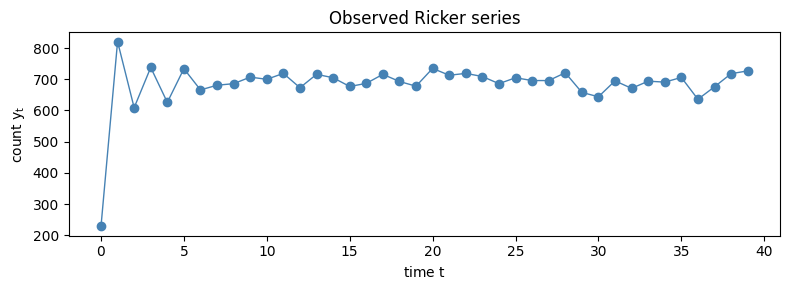

In [3]:
true_params = jnp.log(jnp.array([70.0, 10.0, 1.8]))  # K, phi, r (sorted)
true_params_nat = Record(K=70.0, phi=10.0, r=1.8)
y_obs = ricker.generate_data(true_params, 1, key=jax.random.PRNGKey(0))[0]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(T), np.asarray(y_obs), 'o-', color='steelblue', lw=1)
ax.set(xlabel='time $t$', ylabel='count $y_t$', title='Observed Ricker series')
plt.tight_layout(); plt.show()

### A broad log-space prior

We center each component in the right ballpark but deliberately off the truth, with moderate scale, so MCMC has real work to do. `ProductDistribution` defines an independent prior over named parameters. When all components are TFP-backed (as `Normal` is), `ProductDistribution` automatically exposes a combined TFP distribution for interop with SBI.

In [4]:
prior = ProductDistribution(Normal(loc=jnp.log(60.0), scale=0.3, name="K"),
                            Normal(loc=jnp.log(8.0), scale=0.3, name="phi"),
                            Normal(loc=jnp.log(1.5), scale=0.4, name="r"))

## 2. MCMC via `condition_on`

Because we can write down a closed-form likelihood, the natural inference method is MCMC. We package the prior and the likelihood in a `SimpleModel` and call `condition_on`. The model satisfies `SupportsLogProb`, so the inference registry auto-selects NUTS, exactly as in the Getting Started tutorial.

In [5]:
model_mcmc = SimpleModel(prior, ricker, name='ricker_mcmc')

posterior_mcmc = condition_on(model_mcmc, y_obs)
print(f'Algorithm: {posterior_mcmc.algorithm}')

Algorithm: blackjax_nuts


In [6]:
PARAM_NAMES = ['r', 'K', 'phi']
truth_nat = {name: float(true_params_nat[name]) for name in PARAM_NAMES}


def _fmt(label, means, sds=None):
    sd_iter = sds if sds is not None else [None] * len(means)
    cols = '   '.join(
        f'{n} = {m:6.2f}' + (f' \u00b1 {s:5.2f}' if s is not None else ' ' * 8)
        for n, m, s in zip(PARAM_NAMES, means, sd_iter)
    )
    return f'{label:<26}{cols}'.rstrip()


def summarize(posterior, label):
    """Print ground truth and the (approximate) posterior mean +/- 2 sd."""
    draws = posterior.draws()
    if isinstance(draws, (Record, RecordArray)):
        nat = {name: np.exp(np.asarray(draws[name])) for name in PARAM_NAMES}
    else:
        flat = np.asarray(draws).reshape(-1, 3)
        # Flat array in field-insertion order: K=col0, phi=col1, r=col2
        nat = {'K': np.exp(flat[:, 0]), 'phi': np.exp(flat[:, 1]), 'r': np.exp(flat[:, 2])}
    means = [nat[n].mean() for n in PARAM_NAMES]
    sds = [2 * nat[n].std() for n in PARAM_NAMES]
    truths = [truth_nat[n] for n in PARAM_NAMES]
    print(_fmt('truth', truths))
    print(_fmt(label, means, sds))
    return nat


nat_mcmc = summarize(posterior_mcmc, 'NUTS (closed-form)')

truth                     r =   1.80           K =  70.00           phi =  10.00
NUTS (closed-form)        r =   1.81 ±  0.05   K =  78.07 ± 12.19   phi =   8.94 ±  1.41


## 3. What changes if you only have a simulator?

The Poisson-Ricker model above has a tractable likelihood because the dynamics are deterministic. But real ecological models almost always involve internal randomness (process noise, demographic stochasticity, individual-based simulators), so in practice there is no closed-form likelihood. In those settings the only thing the user can supply is a simulator.

NUTS still works on the toy Ricker, so the point here is not that you *must* switch; it is that you *can*, without changing the model class or the call site:

```python
model_sim = SimpleGenerativeModel(prior, ricker)
posterior = condition_on(model_sim, y_obs, ...)
```

`SimpleGenerativeModel` only requires `generate_data`, never `log_likelihood`. Below we walk through four SBI engines, all reached through `condition_on`.

In [7]:
model_sim = SimpleGenerativeModel(prior, ricker, name='ricker_sim')

### 3a. Amortized neural posterior estimation (NPE)

`learn_amortized_posterior` trains a neural density estimator (a BayesFlow coupling flow by default) to approximate $p(\theta \mid y)$ as a function of $y$. It returns a `BayesFlowModel` that implements `SupportsConditioning`, so `condition_on` calls the trained network directly — one forward pass, no MCMC. The same trained model conditions on any observation of the trained shape.

In [8]:
with silence():
    npe_model = learn_amortized_posterior(prior, ricker, method='npe',
                                          num_simulations=5_000, epochs=60, batch_size=128)
    posterior_npe = condition_on(npe_model, y_obs)

nat_npe = summarize(posterior_npe, 'NPE (direct sampler)')

12:34:45.556 | INFO    | bayesflow - Using backend 'jax'

12:34:47.044 | INFO    | bayesflow - Fitting on dataset instance of OfflineDataset.

12:34:47.045 | INFO    | bayesflow - Building on a test batch.

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

truth                     r =   1.80           K =  70.00           phi =  10.00
NPE (direct sampler)      r =   1.73 ±  0.46   K =  59.16 ± 69.35   phi =  12.46 ± 11.91


### 3b. Emulated likelihood + your favorite MCMC algorithm (NLE)

`learn_amortized_likelihood` trains a network to approximate $p(y \mid \theta)$ instead of the posterior. It returns a `BayesFlowLikelihood` — *just* a likelihood — which we drop into `SimpleModel(prior, learned)` and hand to `condition_on`. The learned log-density is `jax.grad`-transparent, so the standard NUTS path drives it with no special handling; any registered MCMC backend would work.

Our observations are **Poisson counts** — integer-valued — and fitting a continuous flow directly to atoms is ill-posed (the density wants to collapse onto the integers). We pass `dequantize=True`, the recommended setting for integer-valued data: it trains on uniformly jittered counts and scores at the unit-cell midpoint, so the flow models an absolutely continuous target rather than a comb of spikes.

In [9]:
with silence():
    nle_lik = learn_amortized_likelihood(prior, ricker, num_simulations=5_000,
                                         epochs=60, batch_size=128, dequantize=True)
    posterior_nle = condition_on(SimpleModel(prior, nle_lik), y_obs)

nat_nle = summarize(posterior_nle, 'NLE + NUTS')

12:35:16.681 | INFO    | bayesflow - Fitting on dataset instance of OfflineDataset.

12:35:16.681 | INFO    | bayesflow - Building on a test batch.

truth                     r =   1.80           K =  70.00           phi =  10.00
NLE + NUTS                r =   1.86 ±  0.13   K =  81.24 ± 18.36   phi =   8.64 ±  1.81


### 3c. Emulated likelihood-to-evidence ratio (NRE)

`learn_amortized_ratio` trains a classifier to approximate the likelihood-to-evidence ratio $p(y \mid \theta) / p(y)$. Like NLE it returns a likelihood component for `SimpleModel` + `condition_on`, but the estimator is a classifier rather than a density, so it consumes the integer counts **natively** — no `dequantize` needed. The summed per-row scores equal the joint log-likelihood up to a $\theta$-independent constant, which cancels in MCMC: valid for conditioning, but not for absolute-likelihood uses such as model comparison or LOO/WAIC.

In [10]:
with silence():
    nre = learn_amortized_ratio(prior, ricker, num_simulations=5_000,
                                epochs=60, batch_size=128)
    posterior_nre = condition_on(SimpleModel(prior, nre), y_obs)

nat_nre = summarize(posterior_nre, 'NRE + NUTS')

12:35:53.442 | INFO    | bayesflow - Fitting on dataset instance of OfflineDataset.

12:35:53.443 | INFO    | bayesflow - Building on a test batch.

truth                     r =   1.80           K =  70.00           phi =  10.00
NRE + NUTS                r =   1.90 ±  1.44   K =  57.84 ± 36.56   phi =   8.28 ±  5.18


### 3d. Sequential Monte Carlo ABC

SMC-ABC is a non-amortized, likelihood-free method: it iteratively refines a particle approximation to the posterior using the simulator alone. ProbPipe registers an SMC-ABC method against `SimpleGenerativeModel` through the `pyabc` backend, so calling `condition_on` on `model_sim` with `method='pyabc_smcabc'` runs it. We supply problem-specific summary statistics (mean, standard deviation, lag-1 autocorrelation), since identity summaries don't work in $T = 40$ dimensions.

> This section runs once the `pyabc` backend is installed (a later release); until then the cell skips itself.

In [11]:
def ricker_summary(y):
    y = jnp.atleast_2d(y).astype(jnp.float32)
    m, s = y.mean(-1, keepdims=True), y.std(-1, keepdims=True)
    ac1 = jnp.mean((y[:,1:] - m) * (y[:,:-1] - m), -1, keepdims=True) / (s**2 + 1e-6)
    return jnp.concatenate([m, s, ac1], -1)


if HAVE_PYABC:
    with silence():
        posterior_abc = condition_on(model_sim, y_obs, method='pyabc_smcabc',
                                     summary_fn=ricker_summary, n_rounds=4, n_particles=500)
    nat_abc = summarize(posterior_abc, 'SMC-ABC (likelihood-free)')
else:
    nat_abc = None
    print('SMC-ABC requires the pyabc backend (a later release); skipping this cell.')

SMC-ABC requires the pyabc backend (a later release); skipping this cell.


## 4. Comparing the posteriors

All runs go through the same `condition_on` entry point, return `ApproximateDistribution` objects, and feed downstream operations (`mean`, `variance`, `sample`, `predictive_check`, ...) identically. NUTS is the gold standard here because we have a closed-form likelihood. The neural SBI backends concentrate near the truth but are broader: they pay the cost of training a surrogate rather than evaluating the exact log-density. (SMC-ABC joins the comparison once the `pyabc` backend is installed.)

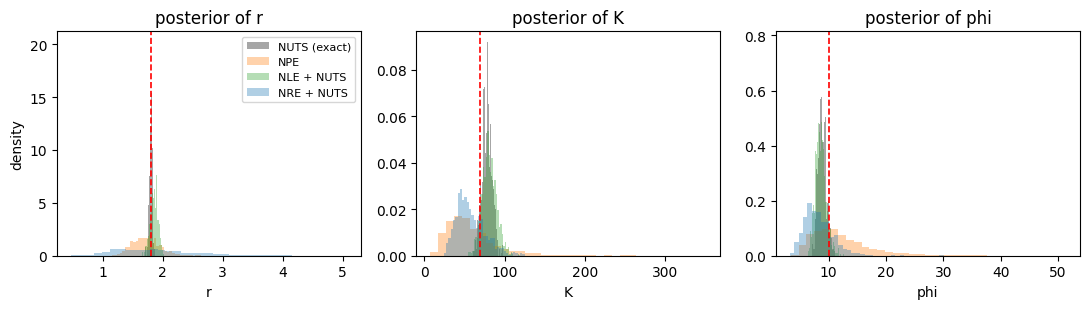

In [12]:
def plot_posteriors(posteriors, colors, truth_nat):
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
    for ax, name in zip(axes, PARAM_NAMES):
        for (label, nat), c in zip(posteriors.items(), colors):
            ax.hist(nat[name], bins=35, density=True, alpha=0.35, color=c, label=label)
        ax.axvline(truth_nat[name], color='red', ls='--', lw=1.2)
        ax.set(xlabel=name, ylabel='density' if name == PARAM_NAMES[0] else None,
               title=f'posterior of {name}')
    axes[0].legend(fontsize=8, loc='upper right')
    plt.tight_layout(); plt.show()


posteriors = {'NUTS (exact)': nat_mcmc, 'NPE': nat_npe, 'NLE + NUTS': nat_nle, 'NRE + NUTS': nat_nre}
colors = ['black', 'tab:orange', 'tab:green', 'tab:blue']
if nat_abc is not None:
    posteriors['SMC-ABC'] = nat_abc
    colors.append('tab:purple')
plot_posteriors(posteriors, colors, truth_nat)

## 5. Simulation-based Inference for the Stochastic Ricker Model

Setting `sigma_p > 0` on the same class adds Gaussian process noise to the log-growth rate, so each time step has a fresh shock:

$$N_{t+1} = N_t \exp\!\left(r (1 - N_t/K) + \epsilon_t\right), \qquad \epsilon_t \sim \mathcal{N}(0, \sigma_p^2).$$

Now $N_{1:T}$ is a latent stochastic process. The integral $p(y \mid \theta) = \int p(y \mid N_{1:T}) \, p(N_{1:T} \mid \theta) \, dN_{1:T}$ has no closed form, and the Poisson `log_likelihood` we used in §2 would silently return the wrong answer (it treats the noisy trajectory as if it were deterministic). We added a check for `sigma_p == 0` on `log_likelihood` for this reason.

The simulator handles both regimes in the same code path, so the prior, the summary statistics, and the `condition_on` call site all carry over. The only difference from §3 is the model wrapper: `SimpleGenerativeModel` instead of `SimpleModel`, because there is no valid log-density to hand to gradient-based MCMC.

log_likelihood refused:  closed-form likelihood only valid for sigma_p=0


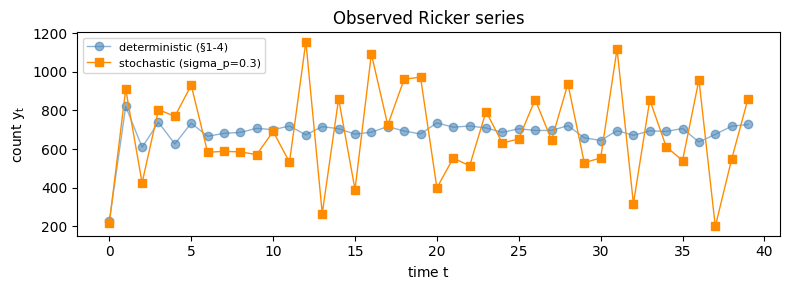

In [13]:
stoch_ricker = RickerObservationModel(T=T, N0=N0, sigma_p=0.3)

# Generate a fresh observed series from the stochastic model.
y_obs_stoch = stoch_ricker.generate_data(true_params, 1, key=jax.random.PRNGKey(7))[0]

# Protocol check: still a GenerativeLikelihood; log_likelihood now errors on use.
assert isinstance(stoch_ricker, GenerativeLikelihood)
try:
    stoch_ricker.log_likelihood(true_params, y_obs_stoch)
except NotImplementedError as e:
    print(f'log_likelihood refused:  {e}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(T), np.asarray(y_obs), 'o-', color='steelblue',
        lw=1, alpha=0.6, label='deterministic (§1-4)')
ax.plot(np.arange(T), np.asarray(y_obs_stoch), 's-', color='darkorange',
        lw=1, label='stochastic (sigma_p=0.3)')
ax.set(xlabel='time $t$', ylabel='count $y_t$', title='Observed Ricker series')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### Fit the stochastic model: only simulation-based methods apply

With no valid log-density we can't use `SimpleModel` + NUTS. We wrap the same class in `SimpleGenerativeModel` for SMC-ABC, and reuse the amortized engines, which only ever needed the simulator. Below we run NPE (and SMC-ABC when `pyabc` is available); the NLE/NRE code from §3 carries over unchanged, just pointed at `stoch_ricker`.

In [14]:
model_sim_stoch = SimpleGenerativeModel(prior, stoch_ricker)

with silence():
    npe_stoch = learn_amortized_posterior(prior, stoch_ricker, method='npe',
                                          num_simulations=5_000, epochs=60, batch_size=128)
    posterior_npe_stoch = condition_on(npe_stoch, y_obs_stoch)

nat_npe_stoch = summarize(posterior_npe_stoch, 'NPE (stochastic)')

if HAVE_PYABC:
    with silence():
        posterior_abc_stoch = condition_on(model_sim_stoch, y_obs_stoch, method='pyabc_smcabc',
                                           summary_fn=ricker_summary, n_rounds=4, n_particles=500)
    nat_abc_stoch = summarize(posterior_abc_stoch, 'SMC-ABC (stochastic)')
else:
    nat_abc_stoch = None
    print('SMC-ABC requires the pyabc backend (a later release); skipping.')

12:36:11.733 | INFO    | bayesflow - Fitting on dataset instance of OfflineDataset.

12:36:11.733 | INFO    | bayesflow - Building on a test batch.

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

truth                     r =   1.80           K =  70.00           phi =  10.00
NPE (stochastic)          r =   1.45 ±  0.67   K =  64.50 ± 72.09   phi =  11.87 ± 10.10
SMC-ABC requires the pyabc backend (a later release); skipping.


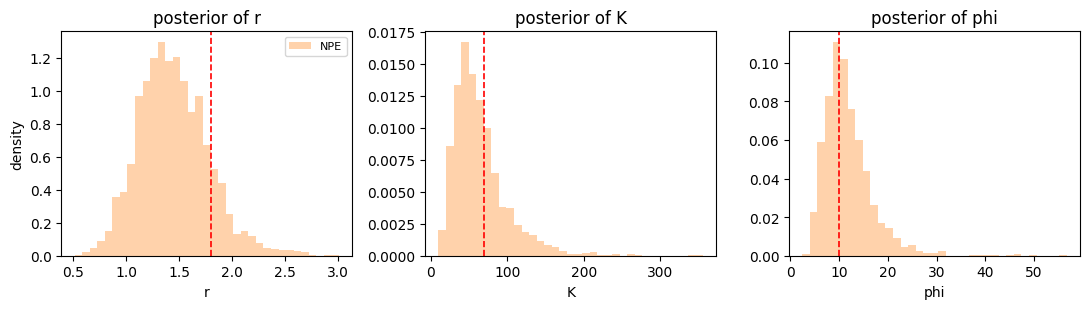

In [15]:
stoch_posteriors = {'NPE': nat_npe_stoch}
stoch_colors = ['tab:orange']
if nat_abc_stoch is not None:
    stoch_posteriors['SMC-ABC'] = nat_abc_stoch
    stoch_colors.append('tab:purple')
plot_posteriors(stoch_posteriors, stoch_colors, truth_nat)

## 6. Protocol-based dispatch

The tutorial has shown `condition_on` reaching several engines without touching the call site. The broader picture is that protocols are ProbPipe's unit of composition: a model exposes a set of capabilities, an inference method declares which capabilities it consumes, and the registry matches them at call time. Swapping NUTS for an emulated likelihood meant registering one class against `SupportsLogProb`, and nothing else in the pipeline had to know.

| Model class | Protocols satisfied | `condition_on` dispatches to |
|---|---|---|
| `SimpleModel(prior, ricker)` | `SupportsLogProb` | NUTS (or HMC / RWMH / nutpie / ...) picked by the inference registry |
| `BayesFlowModel` (from `learn_amortized_posterior`) | `SupportsConditioning` | Direct call into the trained network; no registry lookup |
| `SimpleModel(prior, learned)` (from `learn_amortized_likelihood` / `learn_amortized_ratio`) | `SupportsLogProb` | Any registered MCMC backend, selected automatically or via `method=` |
| `SimpleGenerativeModel(prior, ricker)` | `SupportsSampling` on the prior only | SMC-ABC (`pyabc_smcabc`), registered by the `pyabc` backend |

The same pattern drives the rest of the library: the converter registry matches distribution-to-distribution conversions, `@workflow_function` pushes forward whatever capabilities the input declares, and `predictive_check` negotiates the sampling and data-generation steps the same way. Extending ProbPipe is mostly "add a class and register it" rather than "edit inference, sampling, and downstream analysis separately".

### References

- Ricker, W.E. (1954). Stock and recruitment. *Journal of the Fisheries Research Board of Canada*, 11(5), 559–623.
- Wood, S.N. (2010). [Statistical inference for noisy nonlinear ecological dynamic systems](https://doi.org/10.1038/nature09319). *Nature*, 466, 1102–1104.
- Cranmer, K., Brehmer, J. & Louppe, G. (2020). [The frontier of simulation-based inference](https://doi.org/10.1073/pnas.1912789117). *PNAS*, 117(48), 30055–30062.
- Papamakarios, G. & Murray, I. (2016). [Fast ε-free inference of simulation models with Bayesian conditional density estimation](https://papers.nips.cc/paper/6084). *NeurIPS 2016*. (NPE)
- Papamakarios, G., Sterratt, D. & Murray, I. (2019). [Sequential neural likelihood](https://proceedings.mlr.press/v89/papamakarios19a.html). *AISTATS 2019*. (NLE)
- Hermans, J., Begy, V. & Louppe, G. (2020). [Likelihood-free MCMC with amortized approximate ratio estimators](https://proceedings.mlr.press/v119/hermans20a.html). *ICML 2020*. (NRE)
- Radev, S.T. et al. (2023). [BayesFlow: Amortized Bayesian workflows with neural networks](https://doi.org/10.21105/joss.05702). *JOSS*, 8(89), 5702.
- Sisson, S.A., Fan, Y. & Beaumont, M.A. (2007). [Sequential Monte Carlo without likelihoods](https://doi.org/10.1073/pnas.0607208104). *PNAS*, 104(6), 1760–1765. (SMC-ABC)

## Next steps

- [**API Reference**](../api/inference.md) — full list of registered inference methods, model wrappers, and the `condition_on` operation.
- [**User Guide**](../user_guide.md) — focused examples for individual features.